# Inspect 2D waveforms for DRN units

This notebook visualizes **multi-channel (2D) waveforms** from individual DRN sessions.

**What you'll see:**
1. Mean waveform on peak channel (1D)
2. Template across all unit channels (2D heatmap)
3. Individual spike examples across channels (2D heatmap)

**Recommended use:**
- Inspect spatial waveform spread across channels
- Check for multi-unit contamination
- Validate optotagged units have clean waveforms

In [1]:
import os
import sys
sys.path.append('/root/capsule/code/beh_ephys_analysis')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import spikeinterface as si
import spikeinterface.preprocessing as spre

from utils.beh_functions import session_dirs, get_unit_tbl
from utils.ephys_functions import load_drift

%matplotlib inline

## Configuration

In [2]:
# ==================== USER CONFIGURATION ====================
# Pick a DRN session from session_assets.csv
session = 'behavior_826164_2026-01-27_11-14-13'  # Example DRN session
data_type = 'raw'  # 'raw' or 'curated'

# Filter to optotagged units only?
opto_only = True

# Or specify units manually (set to None to use opto_only filter)
manual_units = None  # e.g., [12, 45, 67]

# Number of random spike examples to show
n_spike_examples = 8

# Number of channels to show (closest to peak channel)
n_channels_to_show = 10
# ============================================================

## Load session data

In [3]:
session_dir = session_dirs(session)
print(f'Session: {session}')
print(f'Data type: {data_type}')

# Load analyzer (has templates/waveforms)
analyzer_path = session_dir[f'postprocessed_dir_{data_type}']
if not os.path.exists(analyzer_path):
    raise FileNotFoundError(f'No analyzer found at {analyzer_path}')

analyzer = si.load(analyzer_path, load_extensions=False)
sparsity = analyzer.sparsity
waveform_extractor = analyzer.get_extension("waveforms")

# Load recording (for raw trace visualization)
compressed_folder = session_dir['session_dir_raw']
stream_name = 'ProbeA'
recording_zarr = [os.path.join(compressed_folder, f) 
                  for f in os.listdir(compressed_folder) 
                  if stream_name in f and 'LFP' not in f][0]

recording = si.read_zarr(recording_zarr)
recording_ps = spre.phase_shift(recording, margin_ms=100.0)
recording_bp = spre.bandpass_filter(recording_ps)
recording_cr = spre.common_reference(recording_bp)

# Load unit table
unit_tbl = get_unit_tbl(session, data_type=data_type, summary=True, ccf_suffix='260817')
print(f'Total units: {len(unit_tbl)}')

# Get channel locations
channel_locations = analyzer.get_channel_locations()
all_channels = analyzer.sparsity.channel_ids
right_left = channel_locations[:, 0] < 20  # Hemisphere indicator

Session: behavior_826164_2026-01-27_11-14-13
Data type: raw
Total units: 9


## Select units to visualize

In [4]:
if manual_units is not None:
    units = manual_units
    print(f'Using manually specified units: {units}')
elif opto_only:
    if 'p_max' not in unit_tbl.columns:
        raise ValueError('No optotagging metrics in unit table. Set opto_only=False or specify manual_units.')
    
    # Use your DRN tagging criteria
    # NOTE: Session-level columns use full names (euc_max_p, corr_max_p, isi_violations_ratio)
    # Combined cross-session table uses abbreviations (eu, corr, isi_violations)
    tagged_mask = (
        (unit_tbl['p_max'] >= 0.5) &
        (unit_tbl['p_max'] <= 1.0) &
        (unit_tbl['lat_max_p'] >= 0.005) &
        (unit_tbl['lat_max_p'] <= 0.02) &
        (unit_tbl['corr_max_p'] >= 0.9) &
        (unit_tbl['euc_max_p'] <= 0.4) &
        (unit_tbl['isi_violations_ratio'] < 0.1)  # ISI violation ratio < 10%
    )
    units = unit_tbl.loc[tagged_mask, 'unit_id'].values
    print(f'Found {len(units)} optotagged units passing all criteria: {units}')
    
    # Print breakdown of filtering
    print(f"\nFiltering breakdown:")
    print(f"  Total units: {len(unit_tbl)}")
    print(f"  p_max ∈ [0.5, 1.0]: {((unit_tbl['p_max'] >= 0.5) & (unit_tbl['p_max'] <= 1.0)).sum()}")
    print(f"  lat_max_p ∈ [5, 20]ms: {((unit_tbl['lat_max_p'] >= 0.005) & (unit_tbl['lat_max_p'] <= 0.02)).sum()}")
    print(f"  corr_max_p ≥ 0.9: {(unit_tbl['corr_max_p'] >= 0.9).sum()}")
    print(f"  euc_max_p ≤ 0.4: {(unit_tbl['euc_max_p'] <= 0.4).sum()}")
    print(f"  isi_violations_ratio < 0.1: {(unit_tbl['isi_violations_ratio'] < 0.1).sum()}")
    print(f"  All criteria combined: {len(units)}")
else:
    units = unit_tbl['unit_id'].values
    print(f'Using all {len(units)} units')

if len(units) == 0:
    raise ValueError('No units selected. Adjust filtering criteria.')

Found 3 optotagged units passing all criteria: [17 22 25]

Filtering breakdown:
  Total units: 9
  p_max ∈ [0.5, 1.0]: 5
  lat_max_p ∈ [5, 20]ms: 8
  corr_max_p ≥ 0.9: 5
  euc_max_p ≤ 0.4: 5
  isi_violations_ratio < 0.1: 9
  All criteria combined: 3


## Visualization function

In [5]:
def plot_2d_waveforms(unit_id, n_examples=8, n_channels=10, save_fig=True):
    """
    Plot 2D waveforms (channels × time) for a single unit.
    
    Parameters
    ----------
    unit_id : int
        Unit ID to visualize
    n_examples : int
        Number of individual spike examples to show
    n_channels : int
        Number of channels to show (centered on peak channel)
    save_fig : bool
        Save figure to ephys_fig_dir
    """
    
    # === Load waveform data ===
    waveforms = waveform_extractor.get_waveforms_one_unit(unit_id=unit_id)
    unit_channels_ind = sparsity.unit_id_to_channel_indices[unit_id]
    right_left_unit = right_left[unit_channels_ind]
    
    # Get unit info
    unit_row = unit_tbl[unit_tbl['unit_id'] == unit_id].iloc[0]
    spike_times = unit_row['spike_times']
    isi_v_ratio = unit_row.get('isi_violations_ratio', np.nan)
    amp = unit_row.get('amp', np.nan)
    peak = unit_row.get('peak', np.nan)
    snr = unit_row.get('snr', np.nan)
    
    # === Compute mean waveform ===
    mean_wf = np.squeeze(np.mean(waveforms, axis=0))
    wf_time = np.linspace(-3, 4, waveforms.shape[1])  # ms, assuming 30kHz
    peak_channel_id = np.argmax(np.ptp(mean_wf, axis=0))
    peak_waveform_mean = mean_wf[:, peak_channel_id]
    peak_waveforms = np.squeeze(waveforms[:, :, peak_channel_id])
    
    # === Select channels to display (same hemisphere, near peak) ===
    peak_hemisphere = right_left_unit[peak_channel_id]
    same_side_mask = (right_left_unit == peak_hemisphere)
    same_side_indices = unit_channels_ind[same_side_mask]
    
    # Sort by distance from peak channel
    distances = np.abs(same_side_indices - unit_channels_ind[peak_channel_id])
    closest_indices = same_side_indices[np.argsort(distances)[:n_channels]]
    closest_indices = np.sort(closest_indices)
    
    # Get channel positions
    channel_positions = channel_locations[closest_indices]
    
    # === Extract template across selected channels ===
    channel_mask = np.isin(unit_channels_ind, closest_indices)
    template_2d = mean_wf[:, channel_mask]  # (time, channels)
    
    # === Get spike samples and select random examples ===
    spike_samples = analyzer.sorting.get_unit_spike_train(unit_id=unit_id)
    
    # Apply drift cuts if available
    unit_drift = load_drift(session, unit_id, data_type=data_type)
    if unit_drift is not None and unit_drift.get('ephys_cut') is not None:
        cut = unit_drift['ephys_cut']
        if cut[0] is not None:
            mask = spike_times >= cut[0]
            spike_samples = spike_samples[mask]
            spike_times = spike_times[mask]
        if cut[1] is not None:
            mask = spike_times <= cut[1]
            spike_samples = spike_samples[mask]
            spike_times = spike_times[mask]
    
    # Select valid spikes (not too close to edges)
    pre_samples = int(0.01 * 30000)  # 10ms
    post_samples = int(0.01 * 30000)
    recording_unit = recording_cr.select_channels(all_channels[closest_indices])
    valid_mask = (
        (spike_samples >= pre_samples) & 
        (spike_samples <= recording_unit.get_num_frames() - post_samples)
    )
    spike_samples_valid = spike_samples[valid_mask]
    
    if len(spike_samples_valid) < n_examples:
        n_examples = len(spike_samples_valid)
    
    spike_inds = np.random.choice(len(spike_samples_valid), size=n_examples, replace=False)
    
    # === Create figure ===
    fig = plt.figure(figsize=(18, 4 + n_examples * 1.5))
    n_cols = 4
    gs = gridspec.GridSpec(
        1 + n_examples, n_cols, 
        height_ratios=[2] + [1]*n_examples,
        width_ratios=[1, 1, 1, 1]
    )
    
    # === Row 0: Summary plots ===
    # Plot 1: 1D peak waveform
    ax = fig.add_subplot(gs[0, 0])
    waveforms_sd = np.std(peak_waveforms, axis=0)
    waveforms_sem = waveforms_sd / np.sqrt(waveforms.shape[0])
    ax.plot(wf_time, peak_waveform_mean, 'k-', linewidth=2, label='Mean')
    ax.fill_between(
        wf_time, 
        peak_waveform_mean - waveforms_sd, 
        peak_waveform_mean + waveforms_sd,
        color='k', alpha=0.2, label='±SD', edgecolor='none'
    )
    ax.fill_between(
        wf_time,
        peak_waveform_mean - waveforms_sem,
        peak_waveform_mean + waveforms_sem,
        color='k', alpha=0.4, label='±SEM', edgecolor='none'
    )
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.5)
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Amplitude (μV)')
    ax.set_title(f'Peak Channel Waveform\nAmp: {amp:.1f}, Peak: {peak:.1f} μV')
    ax.legend(loc='upper right', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Plot 2: 2D template (mean across channels)
    ax = fig.add_subplot(gs[0, 1])
    vmax = np.abs(template_2d).max()
    im = ax.imshow(
        template_2d.T, 
        aspect='auto', 
        cmap='RdBu_r', 
        vmin=-vmax, 
        vmax=vmax,
        extent=[wf_time[0], wf_time[-1], 0, template_2d.shape[1]],
        interpolation='bilinear'
    )
    ax.axvline(0, color='yellow', linestyle='--', linewidth=1)
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Channel index')
    ax.set_title(f'Mean 2D Template\n({template_2d.shape[1]} channels)')
    plt.colorbar(im, ax=ax, label='μV')
    
    # Plot 3: Waveform correlation histogram
    ax = fig.add_subplot(gs[0, 2])
    corr = [np.corrcoef(peak_waveforms[i, :], peak_waveform_mean)[0, 1] 
            for i in range(peak_waveforms.shape[0])]
    ax.hist(corr, bins=50, color='steelblue', edgecolor='none', alpha=0.7)
    ax.axvline(np.mean(corr), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(corr):.3f}')
    ax.set_xlabel('Correlation with mean')
    ax.set_ylabel('Count')
    ax.set_title(f'Waveform Consistency\n({peak_waveforms.shape[0]} waveforms)')
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Plot 4: Channel positions
    ax = fig.add_subplot(gs[0, 3])
    ax.scatter(channel_positions[:, 0], channel_positions[:, 1], s=100, c='steelblue', edgecolor='k', linewidth=1)
    for i, (x, y) in enumerate(channel_positions):
        ax.text(x, y, str(i), ha='center', va='center', color='white', fontsize=8, fontweight='bold')
    # Highlight peak channel
    peak_in_subset = np.where(closest_indices == unit_channels_ind[peak_channel_id])[0][0]
    ax.scatter(
        channel_positions[peak_in_subset, 0], 
        channel_positions[peak_in_subset, 1],
        s=200, facecolors='none', edgecolors='red', linewidth=3
    )
    ax.set_xlabel('ML (μm)')
    ax.set_ylabel('DV (μm)')
    ax.set_title(f'Channel Geometry\n(Red = peak ch {peak_in_subset})')
    ax.set_aspect('equal')
    ax.invert_yaxis()
    
    # === Rows 1+: Individual spike examples ===
    for row_idx, spike_idx in enumerate(spike_inds):
        spike_sample = spike_samples_valid[spike_idx]
        start_frame = int(spike_sample - pre_samples)
        stop_frame = int(spike_sample + post_samples)
        
        curr_signal = recording_unit.get_traces(
            start_frame=start_frame,
            end_frame=stop_frame,
            return_scaled=True
        )
        
        # Plot as 2D heatmap
        ax = fig.add_subplot(gs[row_idx + 1, :])
        vmax_raw = np.abs(curr_signal).max()
        im = ax.imshow(
            curr_signal.T,
            extent=[-pre_samples/30, post_samples/30, 0, len(closest_indices)],
            aspect='auto',
            cmap='RdGy_r',
            vmin=-vmax_raw,
            vmax=vmax_raw,
            interpolation='none'
        )
        ax.axvline(0, color='cyan', linestyle='--', linewidth=1.5, alpha=0.8)
        
        # Mark other spikes in window
        spikes_in_window = spike_samples[
            (spike_samples >= start_frame) & (spike_samples <= stop_frame)
        ]
        spike_times_window = (spikes_in_window - spike_sample) / 30
        for t in spike_times_window:
            if np.abs(t) > 0.1:  # Don't mark the central spike again
                ax.axvline(t, color='orange', linewidth=0.8, alpha=0.6)
        
        ax.set_ylabel('Ch')
        if row_idx == n_examples - 1:
            ax.set_xlabel('Time from spike (ms)')
        else:
            ax.set_xticklabels([])
        
        ax.set_title(f'Example {row_idx+1} (t={spike_times[spike_idx]:.1f}s)', fontsize=9, loc='left')
    
    # === Overall title ===
    opto_str = ''
    if 'p_max' in unit_row:
        opto_str = f"p_max={unit_row['p_max']:.3f}, lat={unit_row['lat_max_p']*1000:.2f}ms, "
    
    fig.suptitle(
        f"{session} | Unit {unit_id} | {opto_str}ISI={isi_v_ratio:.3f}, SNR={snr:.2f}",
        fontsize=12,
        fontweight='bold'
    )
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    
    # === Save ===
    if save_fig:
        save_dir = os.path.join(session_dir[f'ephys_fig_dir_{data_type}'], 'waveforms_2d_check')
        os.makedirs(save_dir, exist_ok=True)
        save_path = os.path.join(save_dir, f'unit_{unit_id}_2d_waveforms.pdf')
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved: {save_path}')
    
    plt.show()
    return fig

## Plot 2D waveforms for selected units


Processing Unit 17


/tmp/ipykernel_34885/813197749.py:176: DeprecationWarning: `return_scaled` is deprecated and will be removed in version 0.105.0. Use `return_in_uV` instead.
  curr_signal = recording_unit.get_traces(
/tmp/ipykernel_34885/813197749.py:176: DeprecationWarning: `return_scaled` is deprecated and will be removed in version 0.105.0. Use `return_in_uV` instead.
  curr_signal = recording_unit.get_traces(
/tmp/ipykernel_34885/813197749.py:176: DeprecationWarning: `return_scaled` is deprecated and will be removed in version 0.105.0. Use `return_in_uV` instead.
  curr_signal = recording_unit.get_traces(
/tmp/ipykernel_34885/813197749.py:176: DeprecationWarning: `return_scaled` is deprecated and will be removed in version 0.105.0. Use `return_in_uV` instead.
  curr_signal = recording_unit.get_traces(
/tmp/ipykernel_34885/813197749.py:176: DeprecationWarning: `return_scaled` is deprecated and will be removed in version 0.105.0. Use `return_in_uV` instead.
  curr_signal = recording_unit.get_traces(


Saved: /root/capsule/scratch/826164/behavior_826164_2026-01-27_11-14-13/ephys/raw/figures/waveforms_2d_check/unit_17_2d_waveforms.pdf


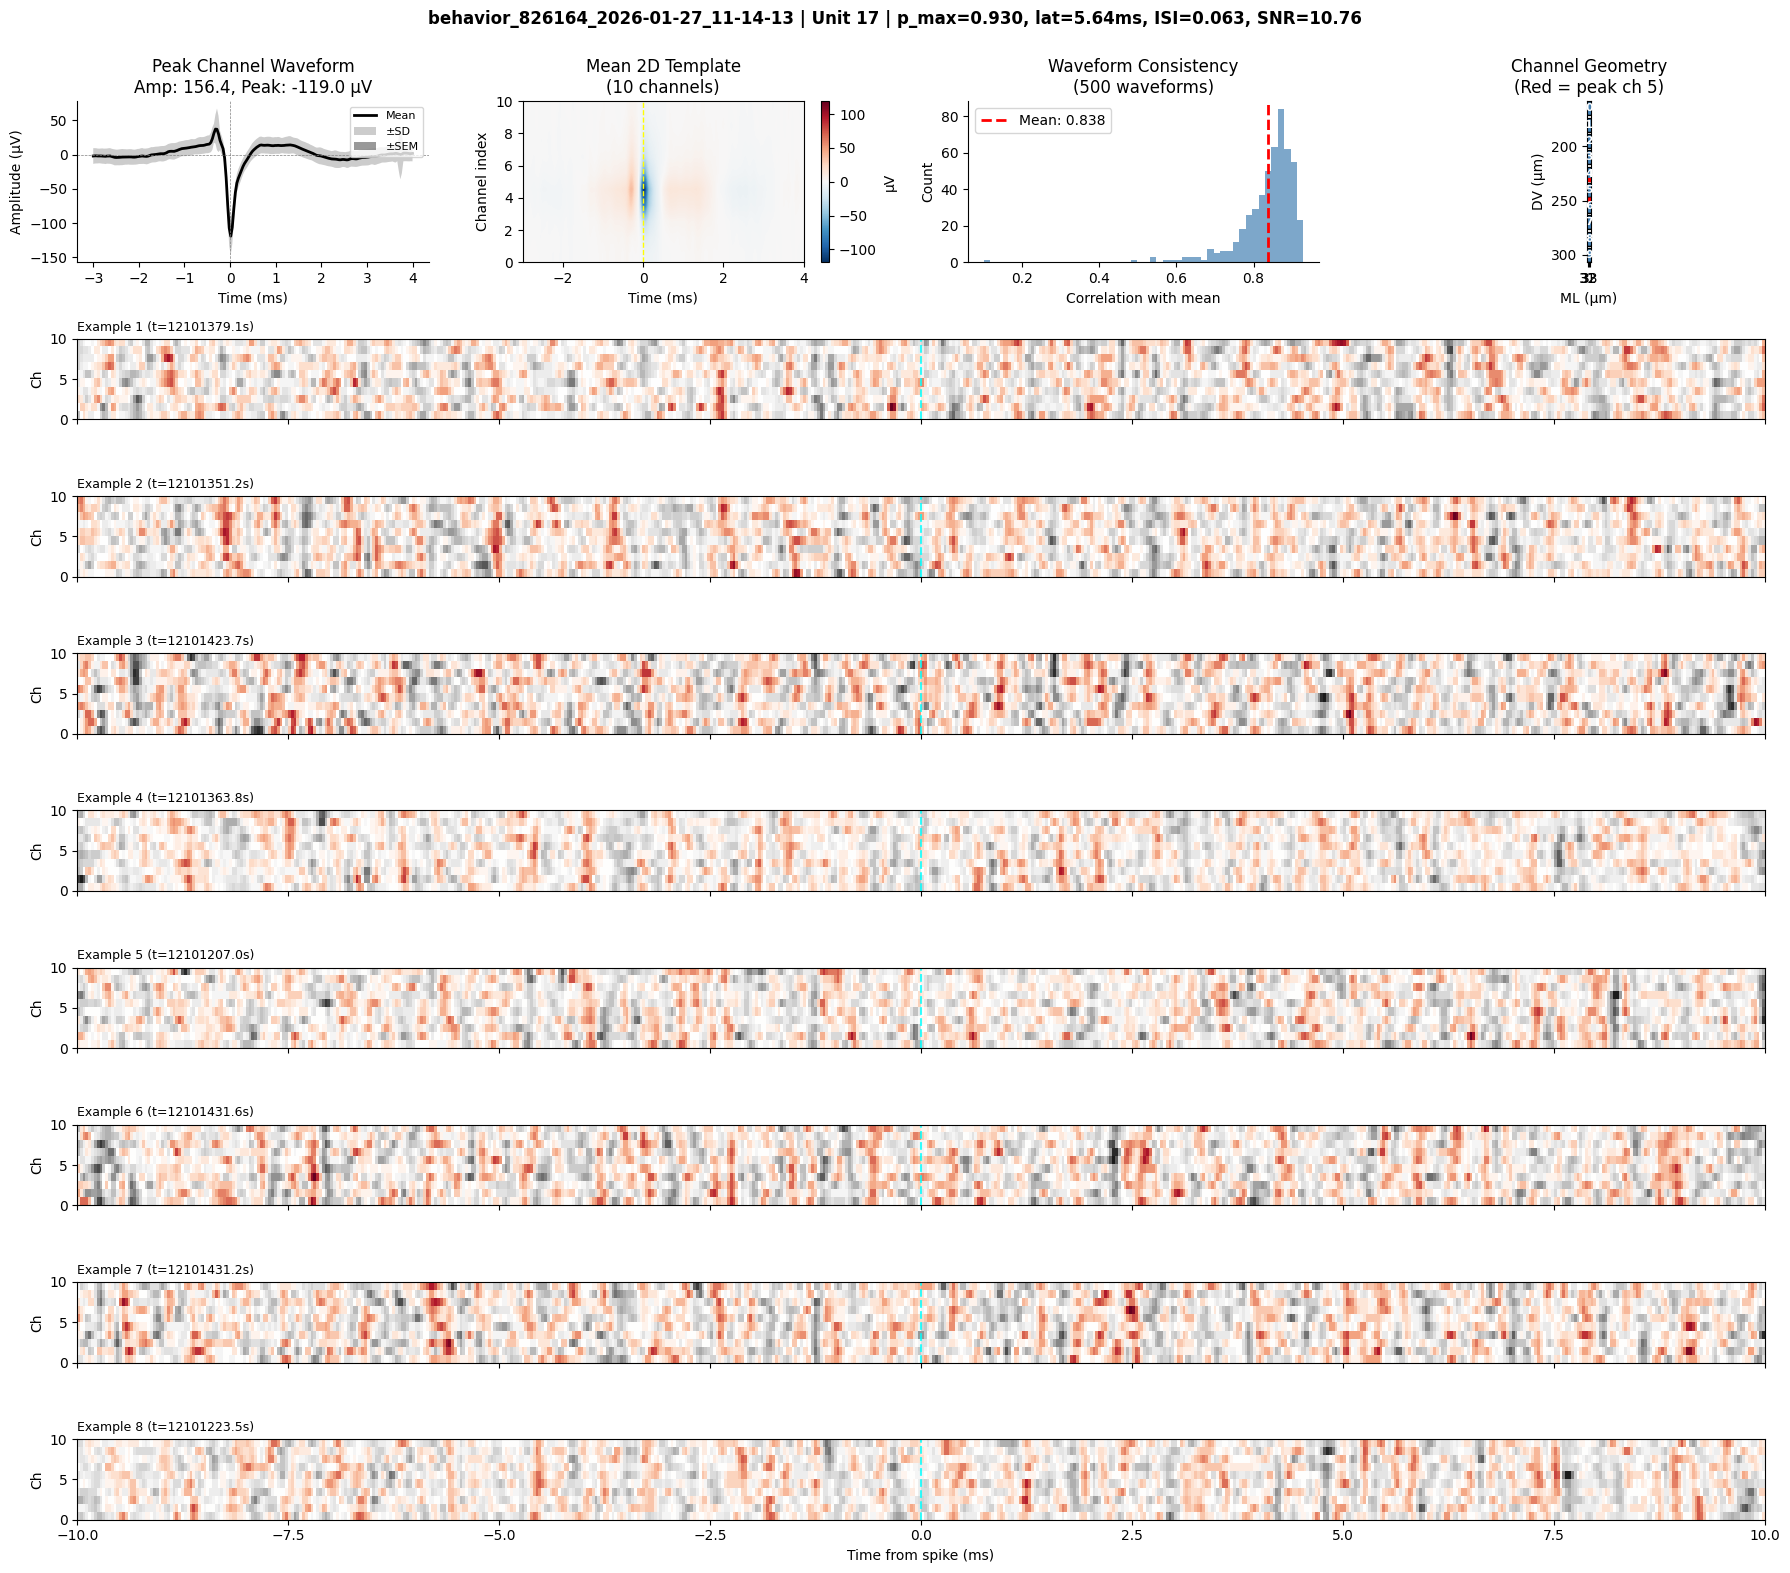


Processing Unit 22


/tmp/ipykernel_34885/813197749.py:176: DeprecationWarning: `return_scaled` is deprecated and will be removed in version 0.105.0. Use `return_in_uV` instead.
  curr_signal = recording_unit.get_traces(
/tmp/ipykernel_34885/813197749.py:176: DeprecationWarning: `return_scaled` is deprecated and will be removed in version 0.105.0. Use `return_in_uV` instead.
  curr_signal = recording_unit.get_traces(
/tmp/ipykernel_34885/813197749.py:176: DeprecationWarning: `return_scaled` is deprecated and will be removed in version 0.105.0. Use `return_in_uV` instead.
  curr_signal = recording_unit.get_traces(
/tmp/ipykernel_34885/813197749.py:176: DeprecationWarning: `return_scaled` is deprecated and will be removed in version 0.105.0. Use `return_in_uV` instead.
  curr_signal = recording_unit.get_traces(
/tmp/ipykernel_34885/813197749.py:176: DeprecationWarning: `return_scaled` is deprecated and will be removed in version 0.105.0. Use `return_in_uV` instead.
  curr_signal = recording_unit.get_traces(


Saved: /root/capsule/scratch/826164/behavior_826164_2026-01-27_11-14-13/ephys/raw/figures/waveforms_2d_check/unit_22_2d_waveforms.pdf


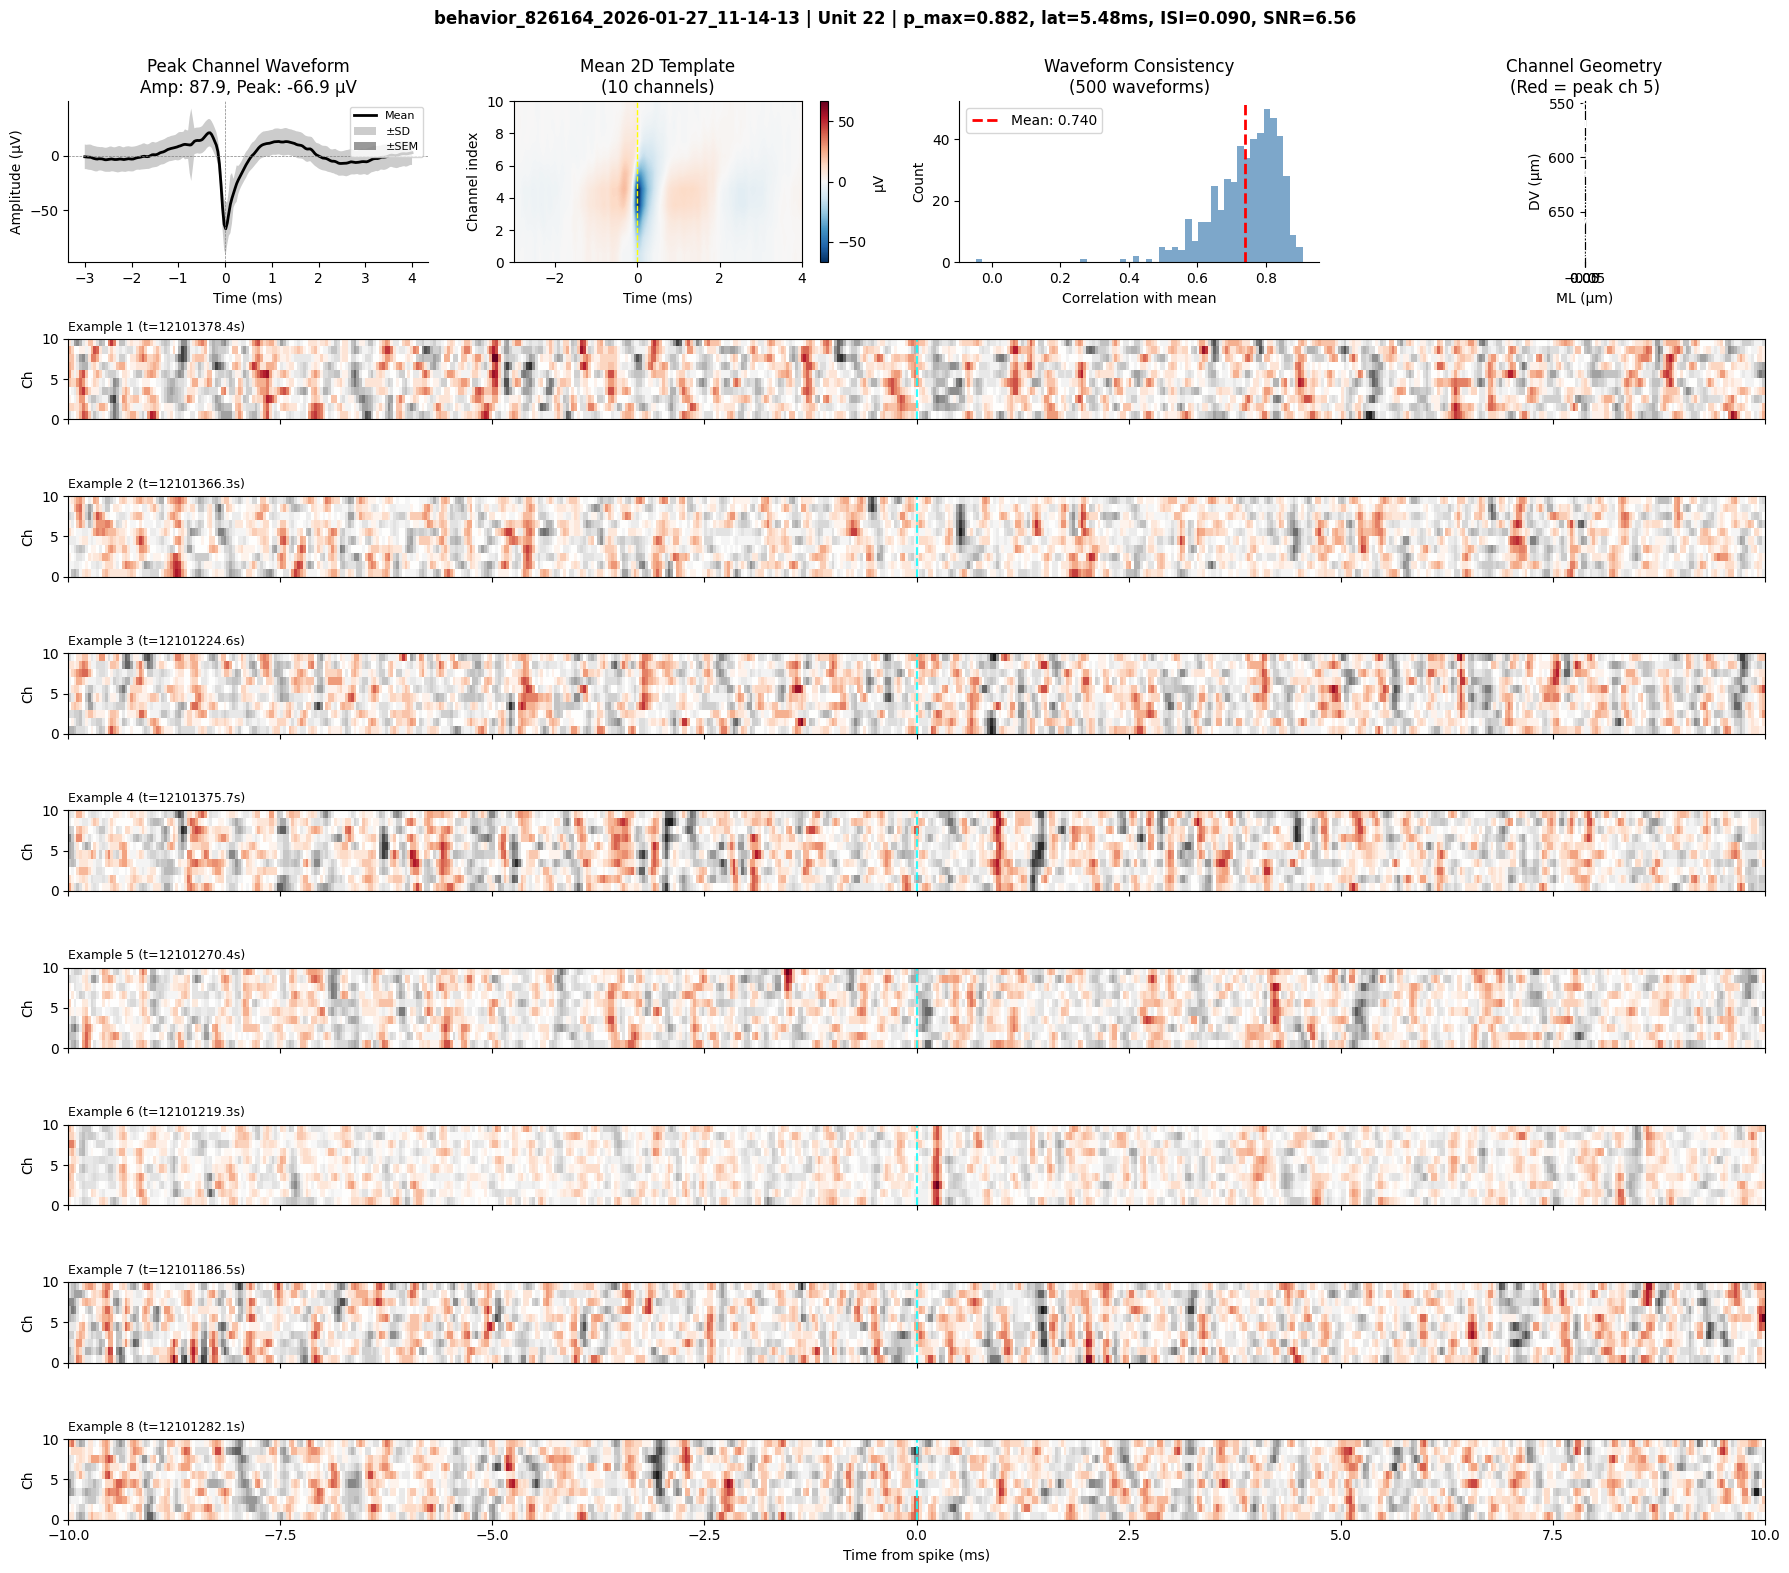


Processing Unit 25


/tmp/ipykernel_34885/813197749.py:176: DeprecationWarning: `return_scaled` is deprecated and will be removed in version 0.105.0. Use `return_in_uV` instead.
  curr_signal = recording_unit.get_traces(
/tmp/ipykernel_34885/813197749.py:176: DeprecationWarning: `return_scaled` is deprecated and will be removed in version 0.105.0. Use `return_in_uV` instead.
  curr_signal = recording_unit.get_traces(
/tmp/ipykernel_34885/813197749.py:176: DeprecationWarning: `return_scaled` is deprecated and will be removed in version 0.105.0. Use `return_in_uV` instead.
  curr_signal = recording_unit.get_traces(
/tmp/ipykernel_34885/813197749.py:176: DeprecationWarning: `return_scaled` is deprecated and will be removed in version 0.105.0. Use `return_in_uV` instead.
  curr_signal = recording_unit.get_traces(
/tmp/ipykernel_34885/813197749.py:176: DeprecationWarning: `return_scaled` is deprecated and will be removed in version 0.105.0. Use `return_in_uV` instead.
  curr_signal = recording_unit.get_traces(


Saved: /root/capsule/scratch/826164/behavior_826164_2026-01-27_11-14-13/ephys/raw/figures/waveforms_2d_check/unit_25_2d_waveforms.pdf


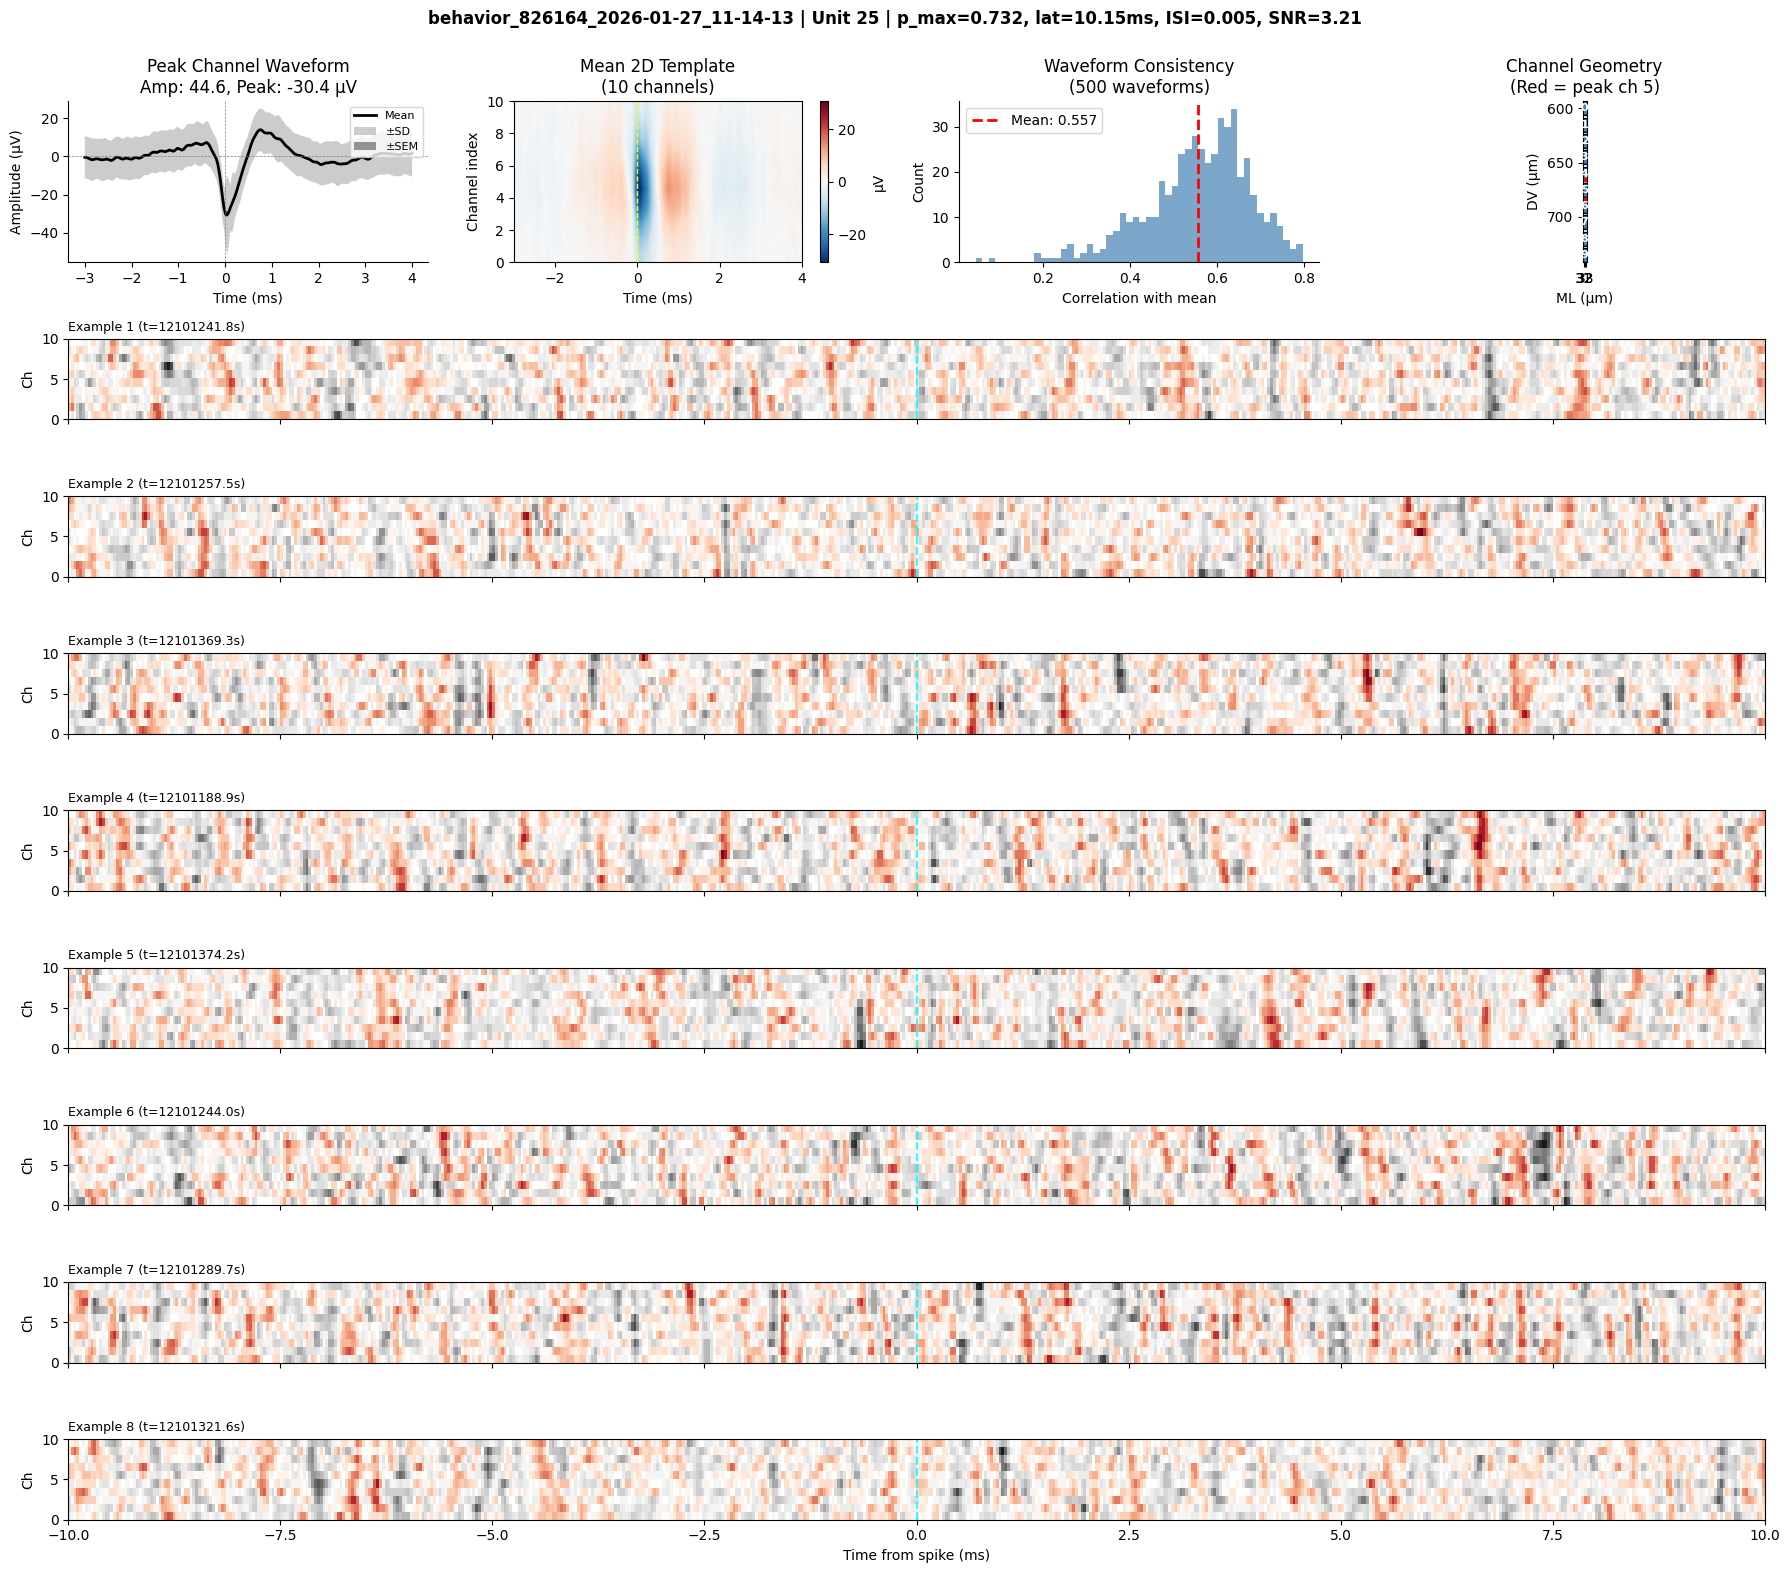


Finished processing 3 units
Output saved to: /root/capsule/scratch/826164/behavior_826164_2026-01-27_11-14-13/ephys/raw/figures/waveforms_2d_check/


In [6]:
# Plot all selected units
for unit_id in units:
    print(f'\n{"="*60}')
    print(f'Processing Unit {unit_id}')
    print(f'{"="*60}')
    try:
        fig = plot_2d_waveforms(
            unit_id, 
            n_examples=n_spike_examples,
            n_channels=n_channels_to_show,
            save_fig=True
        )
        plt.close(fig)
    except Exception as e:
        print(f'ERROR processing unit {unit_id}: {e}')
        continue

print('\n' + '='*60)
print(f'Finished processing {len(units)} units')
print(f"Output saved to: {session_dir[f'ephys_fig_dir_{data_type}']}/waveforms_2d_check/")
print('='*60)

## Optional: Process multiple DRN sessions in batch

In [ ]:
# Uncomment to process multiple sessions
# from joblib import Parallel, delayed

# session_assets = pd.read_csv('/root/capsule/code/data_management/session_assets.csv')
# drn_sessions = session_assets['session_id'].dropna().tolist()

# def process_session(sess):
#     try:
#         sess_dir = session_dirs(sess)
#         if sess_dir[f'postprocessed_dir_{data_type}'] is None:
#             print(f'Skipping {sess}: no postprocessed data')
#             return
#         
#         unit_tbl = get_unit_tbl(sess, data_type=data_type, summary=True, ccf_suffix='260817')
#         # Filter tagged units here...
#         # Then call plot_2d_waveforms for each unit
#         
#     except Exception as e:
#         print(f'Error processing {sess}: {e}')

# # Run in parallel
# Parallel(n_jobs=4)(delayed(process_session)(sess) for sess in drn_sessions[:5])